In [68]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface import WaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
Dataset = LoadDataset()
Dataset.set_iamge(80)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


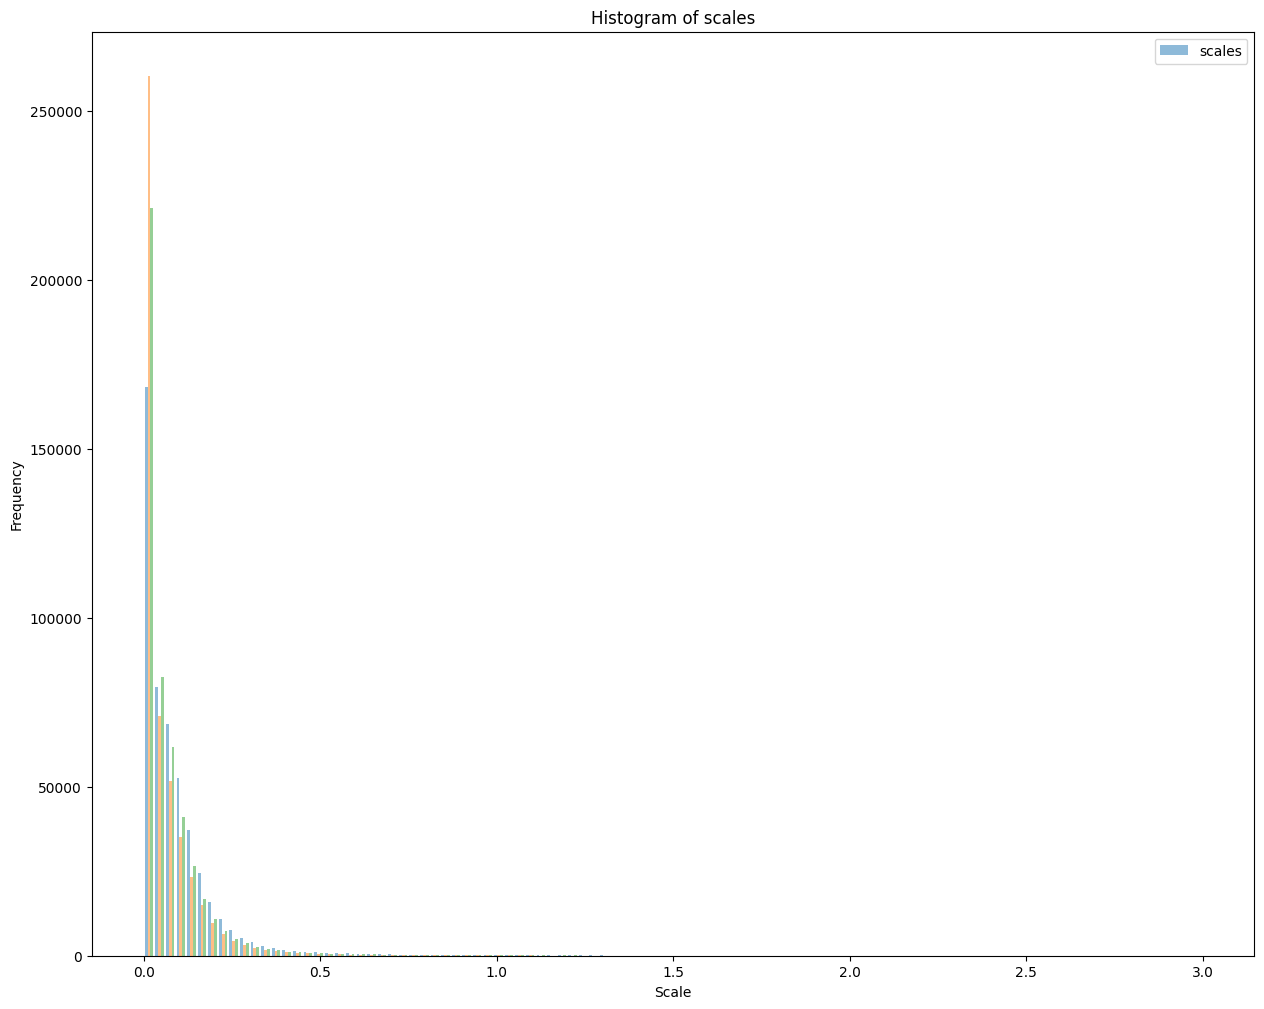

In [70]:
# show histogram of scales
plt.figure()
plt.hist(scales.detach().cpu().numpy().clip(max=3), bins=100, alpha=0.5, label='scales')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales')
plt.legend()
plt.show()

↑ マイナスにならないのがおかしい。
scales は、実数値で読み出されている

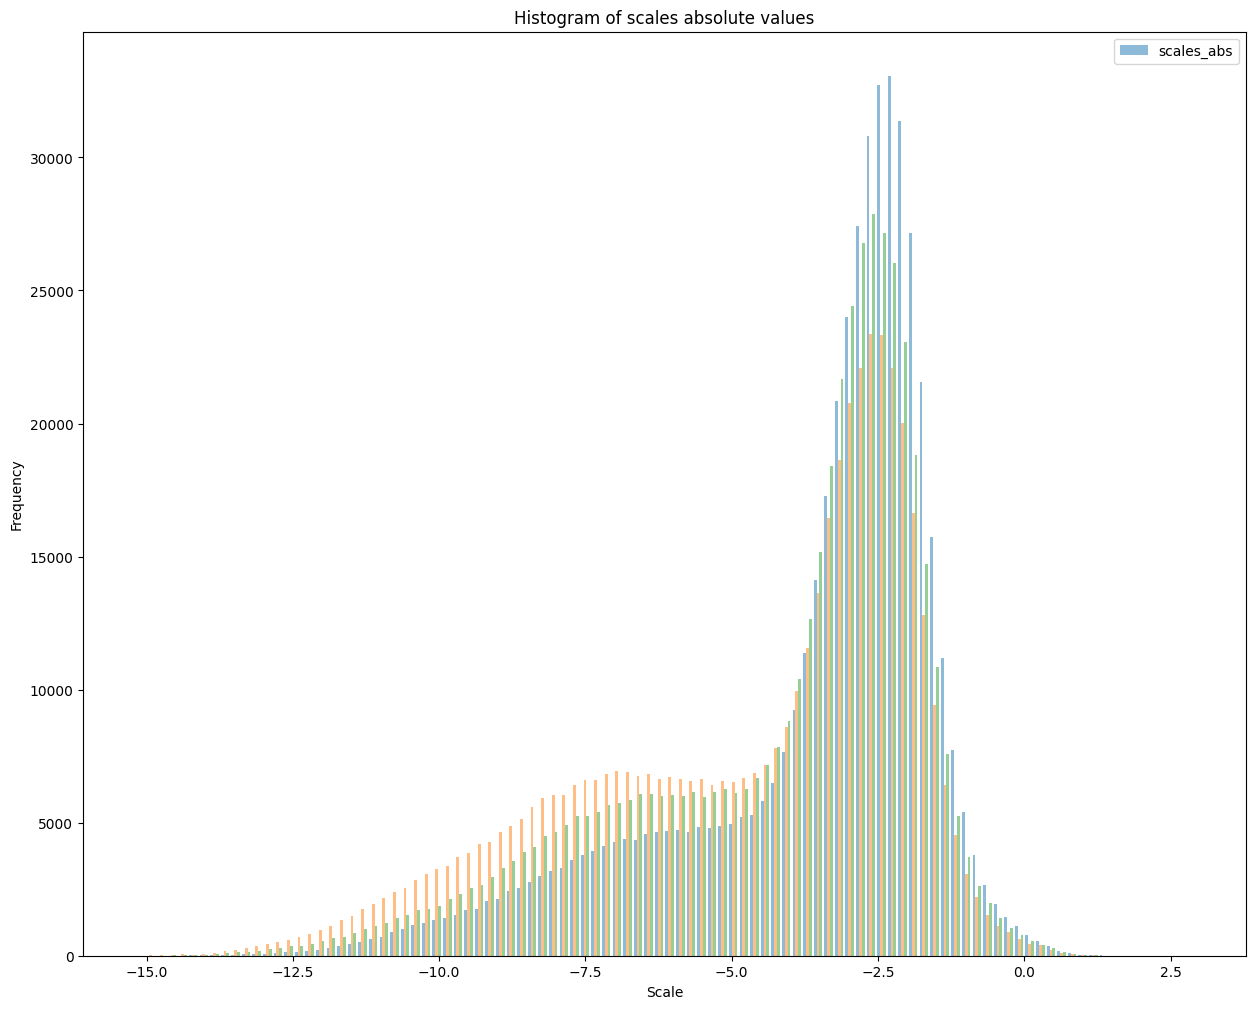

In [71]:
# show histogram of scales absolute values
plt.figure()
plt.hist(torch.log(scales).detach().cpu().numpy().clip(max=3), bins=100, alpha=0.5, label='scales_abs')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales absolute values')
plt.legend()
plt.show()

In [72]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSurface(
    means=means,
    quats=quats,
    scales=scales,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=True,
)

t_means, t_quats = WS.transform_to_appearance()
t_scales = WS.scale_correction_as_real()

map_colors = combert_into_colormap(WS.scale_correction_factor, colormap='plasma')

/home/taiki/try-papers/gsplat/optical/surface.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.n = torch.tensor(n, dtype=torch.float32, device=device, requires_grad=False)
/home/taiki/try-papers/gsplat/optical/surface.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.plane = torch.tensor(plane, dtype=torch.float32, device=device, requires_grad=False)


In [73]:
print(colors.shape)
print(map_colors.shape)

print(torch.log(WS.scale_correction_factor).unsqueeze(-1)) 
print(WS.volume_compression_ratio)

scales_log = WS.scales
t_scales_log = t_scales

scales_log = torch.log(scales_log)
t_scales_log = torch.log(t_scales_log)

volume_compression_ratio = WS.volume_compression_ratio
scale_correction_factor = WS.scale_correction_factor

torch.Size([493170, 1, 3])
torch.Size([493170, 1, 3])
tensor([[-0.5791],
        [-0.6535],
        [-0.7371],
        ...,
        [-0.6231],
        [-0.5979],
        [-1.1995]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
tensor([0.1760, 0.1408, 0.1095,  ..., 0.1542, 0.1664, 0.0274], device='cuda:0',
       grad_fn=<AbsBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4699299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.083941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4293456].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.035656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4001914].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.040226].
Clipping input data to the valid rang

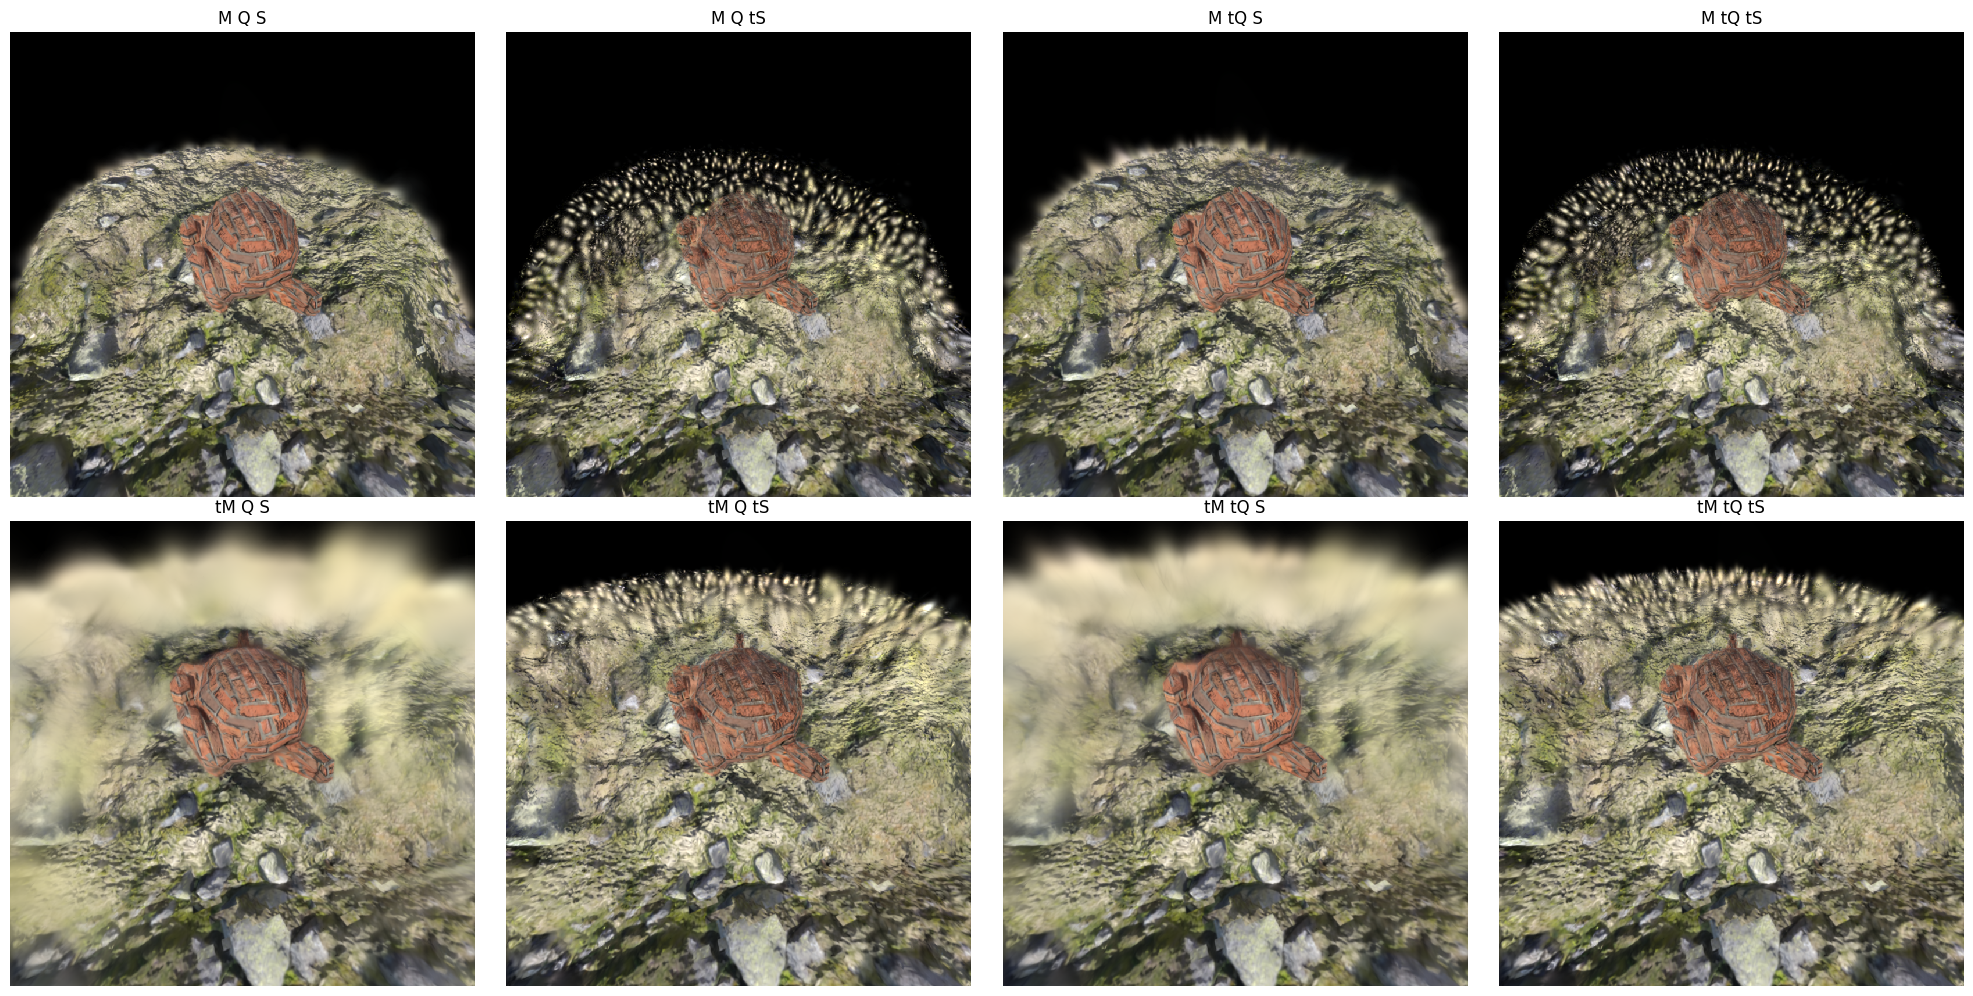

In [74]:
base_data = {
    "means": means,
    "quats": quats,
    "scales": scales,
}
transformed_data = {
    "means": t_means,
    "quats": t_quats,
    "scales": t_scales,
}


compare_rasterization_variants(
    base_data=base_data,
    transformed_data=transformed_data,
    opacities=opacities,
    # colors=map_colors,
    colors=colors,
    worldtocam=worldtocam,
    Ks=K,
    width=width,
    height=height
)

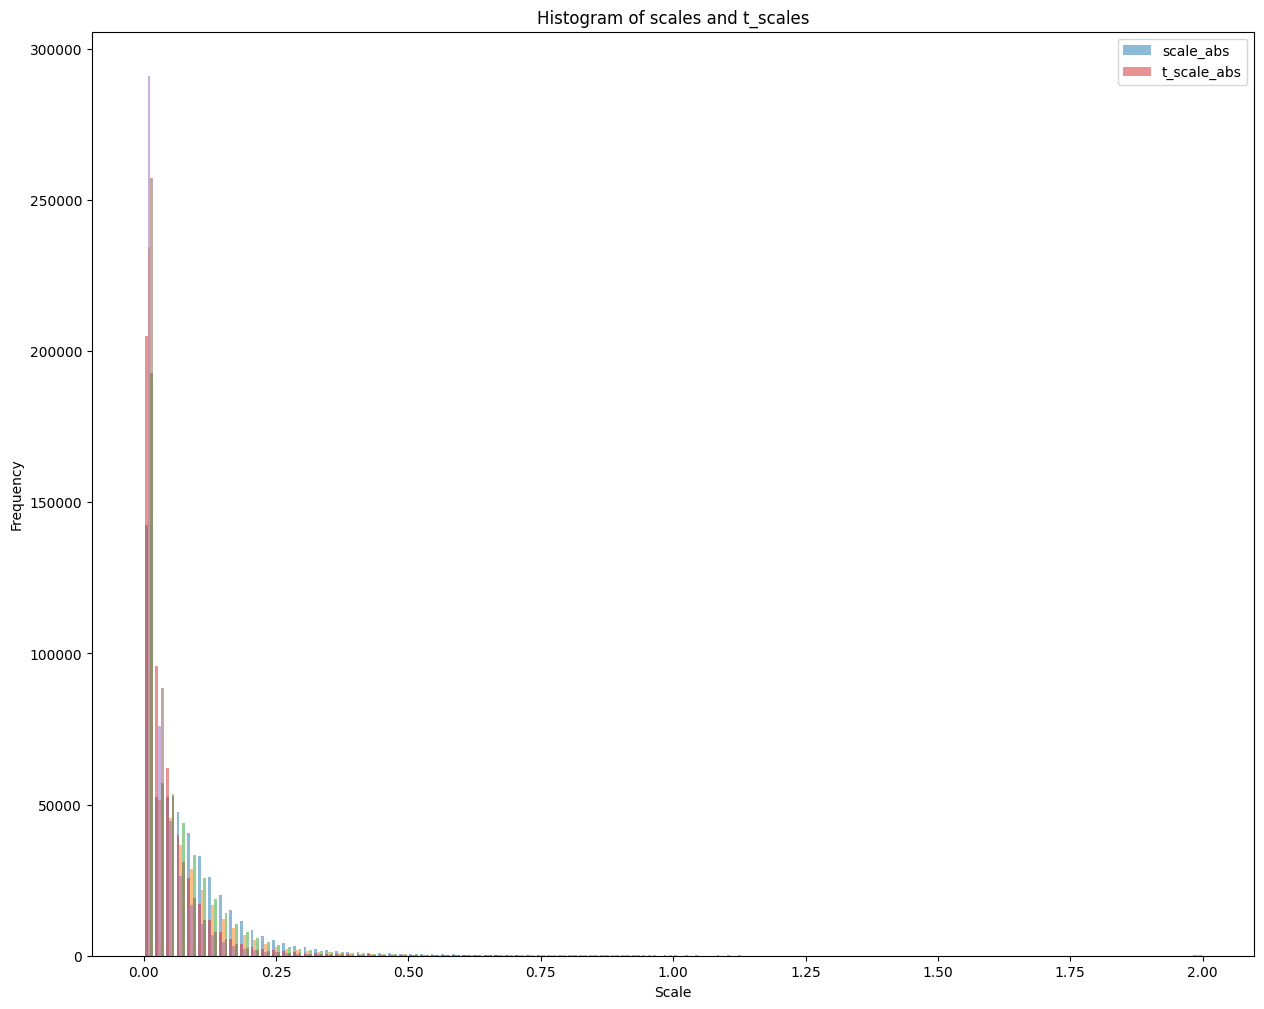

In [75]:
# show histogram of scale 
plt.figure()
plt.hist(scales.detach().cpu().numpy().clip(max=2), bins=100, alpha=0.5, label='scale_abs')
plt.hist(t_scales.detach().cpu().numpy().clip(max=2), bins=100, alpha=0.5, label='t_scale_abs')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales and t_scales')
plt.legend()

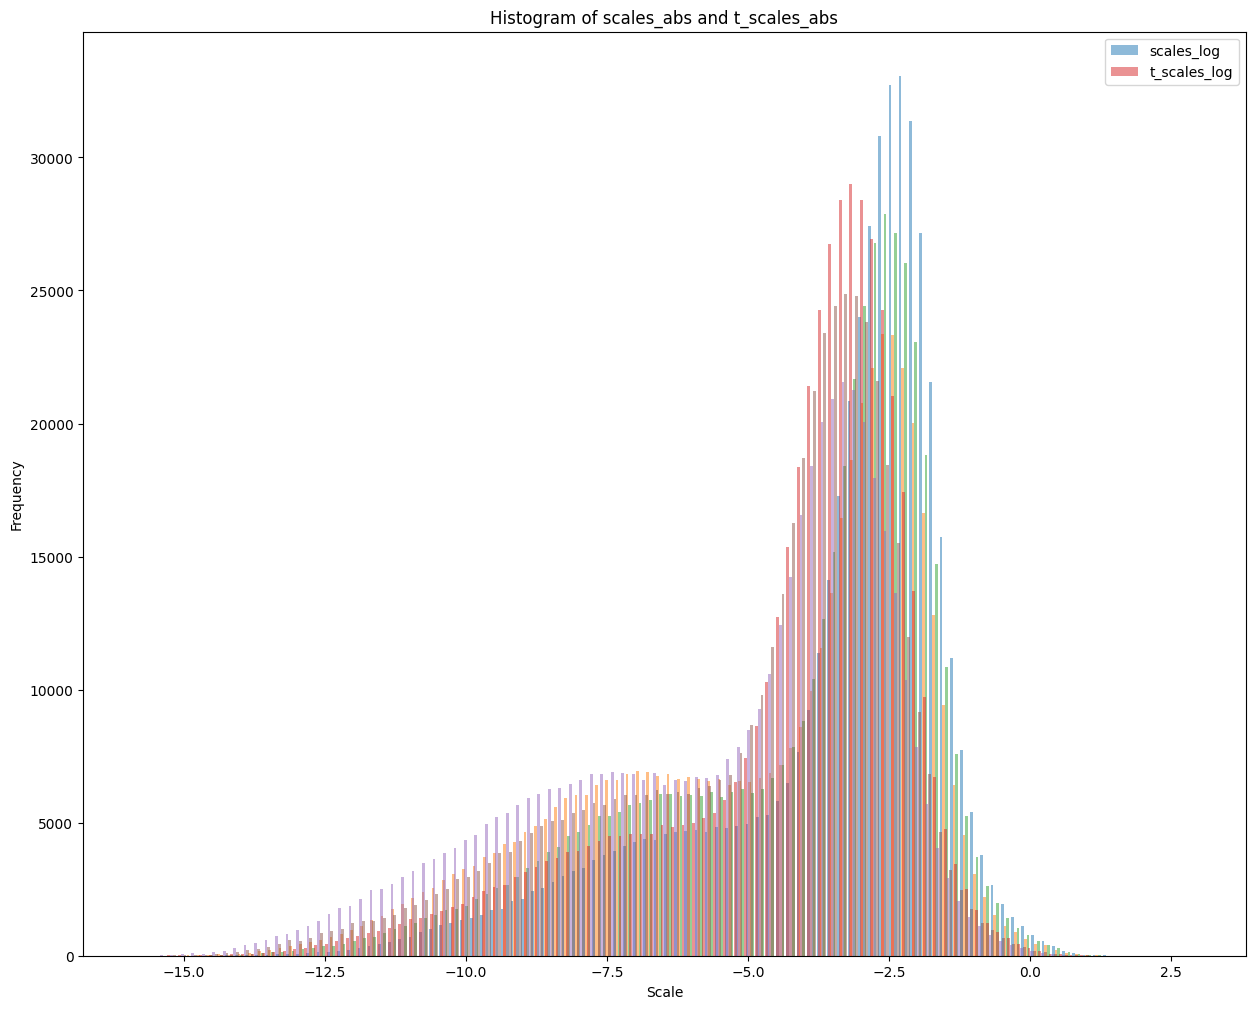

In [76]:
# show histogram of scales_abs
plt.figure()
plt.hist(scales_log.detach().cpu().numpy().clip(max=10), bins=100, alpha=0.5, label='scales_log')
plt.hist(t_scales_log.detach().cpu().numpy().clip(max=10), bins=100, alpha=0.5, label='t_scales_log')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales_abs and t_scales_abs')
plt.legend()
plt.show()


